# Analys av hälsostudie – Del 1

Här börjar vi utforska en hälsostudie med 800 personer.  
Vi ska kolla ålder, vikt, blodtryck, rökning – och se om det finns mönster.  
Vi ska göra detta steg för steg, så vi förstår vad datan egentligen säger!

In [1]:
# Vi importerar verktyg vi behöver
# Pandas för data, NumPy, Matplotlib för grafer, SciPy för tester
# Källa: Videor (moduler), (NumPy), (Pandas)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Sätter en "seed" så alla får exakt samma slump tal
# Källa: Video - Reproducerbarhet
np.random.seed(42)

# Laddar data från CSV-filen – ligger i mappen "data"
# Källa: Videor (CSV), (Pandas read_csv)
df = pd.read_csv("data/dataset.csv")

# Kollar snabbt de första raderna och ser att allt e på plats.
# Källa: Video (df.head)
df.head()

,id,age,sex,height,weight,systolic_bp,cholesterol,smoker,disease
0,1,57,F,168.9,65.8,141.8,4.58,No,0
1,2,47,M,180.4,95.9,144.8,5.18,Yes,0
2,3,59,F,169.9,82.2,151.7,6.16,No,0
3,4,72,M,157.7,93.1,151.0,6.63,No,0
4,5,46,M,192.6,104.1,144.1,5.21,No,0


## Beskrivande statistik – vad säger siffrorna.

Nu räknar vi ut medel, median, min och max för ålder, vikt, längd, blodtryck och kolesterol.  
Detta ger oss en snabb bild av hur deltagaren ser ut

In [2]:
# Väljer kolumnerna vi vill kolla på

columns = ["age", "weight", "height", "systolic_bp", "cholesterol"]

# Snabb överblick med Pandas describe

print("Automatisk sammanfattning:")
print(df[columns].describe())

# Räknar också manuellt ifall att

print("\n Manuellt räknat – steg för steg:")
for col in columns:
    mean_val = df[col].mean()
    median_val = df[col].median()
    min_val = df[col].min()
    max_val = df[col].max()
    print(f"{col}: medel = {mean_val:.2f}, median = {median_val:.2f}, min = {min_val:.2f}, max = {max_val:.2f}")

Automatisk sammanfattning:
              age      weight      height  systolic_bp  cholesterol
count  800.000000  800.000000  800.000000   800.000000   800.000000
mean    49.426250   73.413000  171.849250   149.178625     4.929150
std     14.501118   13.685059    9.804259    12.793360     0.848413
min     18.000000   33.700000  144.400000   106.800000     2.500000
25%     39.000000   64.800000  164.775000   140.900000     4.327500
50%     50.000000   73.200000  171.350000   149.400000     4.970000
75%     59.000000   82.600000  178.925000   157.600000     5.482500
max     90.000000  114.400000  200.400000   185.900000     7.880000

 Manuellt räknat – steg för steg:
age: medel = 49.43, median = 50.00, min = 18.00, max = 90.00
weight: medel = 73.41, median = 73.20, min = 33.70, max = 114.40
height: medel = 171.85, median = 171.35, min = 144.40, max = 200.40
systolic_bp: medel = 149.18, median = 149.40, min = 106.80, max = 185.90
cholesterol: medel = 4.93, median = 4.97, min = 2.50, max =

## Grafer – vad ser vi i datan?

Ritar tre enkla grafer för att få en visuell känsla för hälsostudien:  
- Hur ser blodtrycket ut? (histogram)  
- Finns skillnad i vikt mellan män och kvinnor? (boxplot)  
- Hur många röker egentligen? (stapeldiagram)  

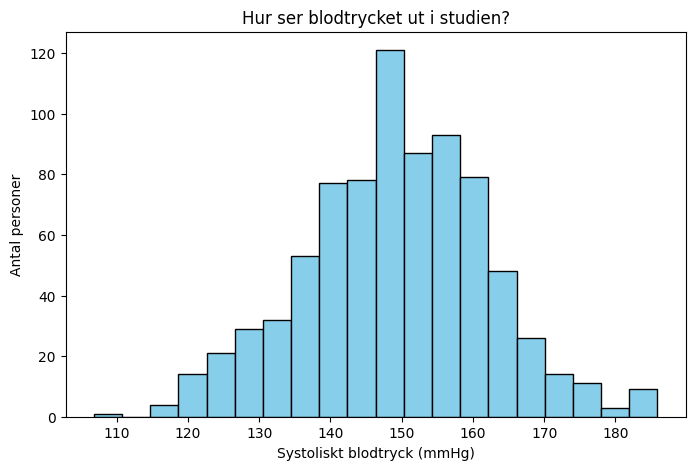

In [3]:
# Ritar histogram för att se hur blodtrycket är fördelat
# är det normalfördelat?
# Videor - Matplotlib

plt.figure(figsize=(8, 5))
plt.hist(df["systolic_bp"], bins=20, color="skyblue", edgecolor="black")
plt.title("Hur ser blodtrycket ut i studien?")
plt.xlabel("Systoliskt blodtryck (mmHg)")
plt.ylabel("Antal personer")
plt.show()

<Figure size 600x600 with 0 Axes>

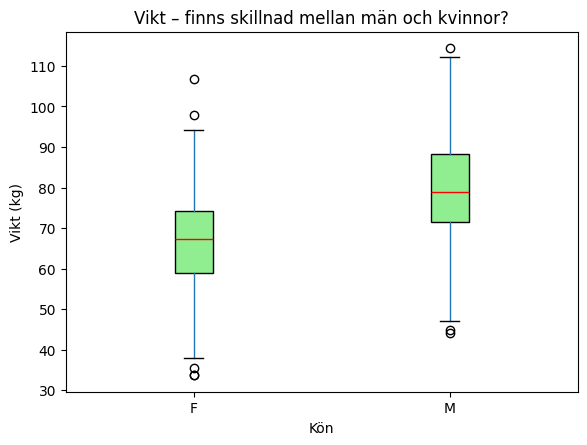

In [4]:
# Om vi gör en boxplot, kan vi jämföra vikt mellan män och kvinnor
# Blir det någon skillnad? Medianen, spridningen – allt syns på en gång.
# Video - Att välja rätt figur

plt.figure(figsize=(6, 6))
df.boxplot(column="weight", by="sex", grid=False, patch_artist=True,
           boxprops=dict(facecolor="lightgreen", color="black"),
           medianprops=dict(color="red"))
plt.title("Vikt – finns skillnad mellan män och kvinnor?")
plt.suptitle("")  # Tar bort undertitel
plt.xlabel("Kön")
plt.ylabel("Vikt (kg)")
plt.show()

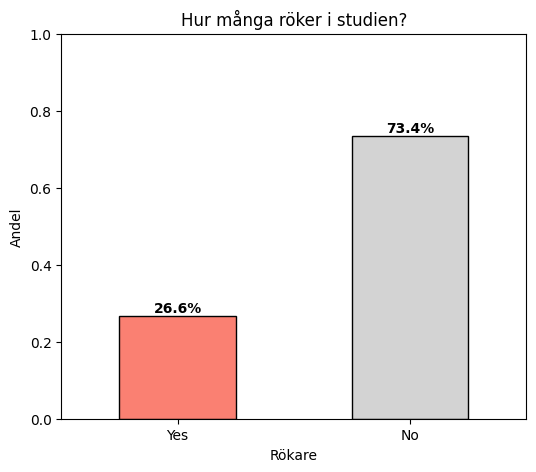

In [5]:
# Nu kollar vi hur många som röker – stapeldiagram med procent.
# Blir det en stor skillnad? Är det rimligt?
# Video - Matplotlib

smoker_counts = df["smoker"].value_counts(normalize=True)  # Andel
smoker_counts = smoker_counts[["Yes", "No"]]  # Yes kommer först

plt.figure(figsize=(6, 5))
smoker_counts.plot(kind="bar", color=["salmon", "lightgray"], edgecolor="black")
plt.title("Hur många röker i studien?")
plt.xlabel("Rökare")
plt.ylabel("Andel")
plt.xticks(rotation=0)
plt.ylim(0, 1)

# Lägger till procent ovanpå – det blir enkelt att läsa
for i, v in enumerate(smoker_counts):
    plt.text(i, v + 0.01, f"{v:.1%}", ha="center", fontweight="bold")

plt.show()

## Simulering – hur kan slumpen ser ut?

Ska räkna först den riktiga andelen med sjukdom.  
Sen simulerar 1000 nya personer med samma chans – vad blir det då?  
Blir det nära verkligheten?

In [7]:
# Räknar riktig andel med sjukdom (1 = ja)

disease_prop = df["disease"].mean()
print(f"Riktig andel med sjukdom: {disease_prop:.1%}")

# Simulerar 1000 nya personer med samma sannolikhet
# Video (sampling och variation)

simulated = np.random.binomial(n=1, p=disease_prop, size=1000)
simulated_prop = simulated.mean()

print(f"Simulerad andel: {simulated_prop:.1%}")
print(f"Skillnad: {abs(disease_prop - simulated_prop):.2%}")

Riktig andel med sjukdom: 5.9%
Simulerad andel: 6.7%
Skillnad: 0.83%


## Konfidensintervall – hur säker är man på blodtrycket?

Räknar 95%-ish intervall för medelblodtrycket.  
Om intervallet är small -- då är jag säker. Om det e bredd -- mer data behövs

In [8]:
# Räknar medel och standardavvikelse för blodtrycket
# Statistik

mean_bp = df["systolic_bp"].mean()
std_bp = df["systolic_bp"].std()
n = len(df)

print(f"Medelblodtryck: {mean_bp:.1f} mmHg")
print(f"Standardavvikelse: {std_bp:.1f}")
print(f"Antal personer: {n}")

# 95% konfidensintervall med normalapprox.
# Video (konfidensintervall)

ci = stats.norm.interval(0.95, loc=mean_bp, scale=std_bp / np.sqrt(n))
print(f"95% konfidensintervall: [{ci[0]:.1f}, {ci[1]:.1f}] mmHg")

Medelblodtryck: 149.2 mmHg
Standardavvikelse: 12.8
Antal personer: 800
95% konfidensintervall: [148.3, 150.1] mmHg


## Hypotesprövning – har rökare högre blodtryck?

H₀: Rökare och icke-rökare har samma medelblodtryck.  
H₁: Rökare har högre medelblodtryck.  

Vi kör ett ensidigt t-test. Om p-värde < 0.05 -- förkastar vi H₀

In [9]:
# Delar upp i rökare och icke-rökare
# Video (Rensa och sammanfatta)

smokers = df[df["smoker"] == "Yes"]["systolic_bp"]
non_smokers = df[df["smoker"] == "No"]["systolic_bp"]

print(f"Rökare: {len(smokers)} personer, medel = {smokers.mean():.1f} mmHg")
print(f"Icke-rökare: {len(non_smokers)} personer, medel = {non_smokers.mean():.1f} mmHg")

# Ensidigt t-test: rökare > icke-rökare?
# Video (Hypotesprövning)

t_stat, p_value = stats.ttest_ind(smokers, non_smokers, alternative="greater")

print(f"\nT-värde: {t_stat:.2f}")
print(f"P-värde (ensidigt): {p_value:.4f}")

# Slutsats

if p_value < 0.05:
    print("Förkastar H₀: Rökare har signifikant högre blodtryck!")
else:
    print("Kan inte förkasta H₀: Ingen tydlig skillnad (p ≥ 0.05)")

Rökare: 213 personer, medel = 149.5 mmHg
Icke-rökare: 587 personer, medel = 149.1 mmHg

T-värde: 0.46
P-värde (ensidigt): 0.3225
Kan inte förkasta H₀: Ingen tydlig skillnad (p ≥ 0.05)
